In [10]:
from itertools import combinations

def find_stable_matchings(edges):
    left_part = set()
    right_part = set()

    for u, v in edges:
        left_part.add(u)
        right_part.add(v)

    all_edges = list(set(edges))

    def is_stable_matching(match):
        used_left = set()
        used_right = set()

        for u, v in match:
            if u in used_left or v in used_right:
                return False
            used_left.add(u)
            used_right.add(v)

        return True

    best_size = 0

    for size in range(min(len(left_part), len(right_part)), 0, -1):
        for idxs in combinations(range(len(all_edges)), size):
            current_matching = {all_edges[i] for i in idxs}
            if is_stable_matching(current_matching):
                best_size = size
                break
        if best_size > 0:
            break

    stable_matchings = []
    for idxs in combinations(range(len(all_edges)), best_size):
        current_matching = {all_edges[i] for i in idxs}
        if is_stable_matching(current_matching):
            stable_matchings.append(current_matching)

    return stable_matchings


edges = [
    ('x1', 'y3'), ('x2', 'y1'), ('x2', 'y2'),
    ('x3', 'y2'), ('x3', 'y3'), ('x3', 'y4'),
    ('x4', 'y2'), ('x4', 'y3'),
    ('x5', 'y3'), ('x5', 'y4'), ('x5', 'y5')
]

result = find_stable_matchings(edges)
for matching in result:
    print(sorted(matching))

[('x1', 'y3'), ('x2', 'y1'), ('x3', 'y4'), ('x4', 'y2'), ('x5', 'y5')]


n = 2: среднее = 0.000114, СКО = 0.000317
n = 3: среднее = 0.000035, СКО = 0.000035
n = 4: среднее = 0.000154, СКО = 0.000081
n = 5: среднее = 0.002146, СКО = 0.001870
n = 6: среднее = 0.021200, СКО = 0.028771
n = 7: среднее = 0.452667, СКО = 0.375510


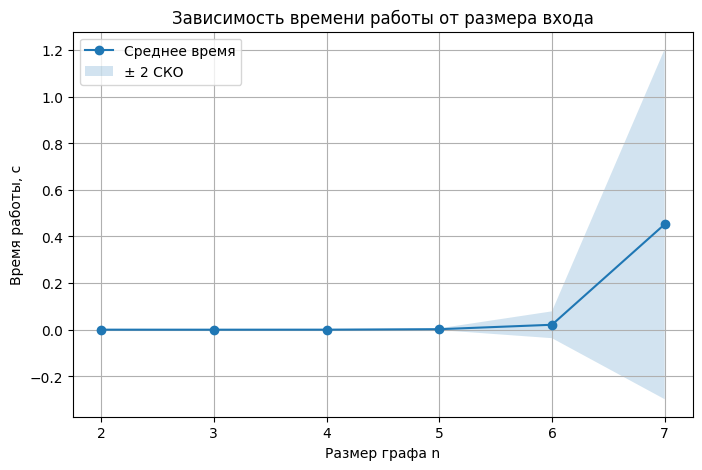


Мат. ожидание: 0.001558
СКО: 0.001986


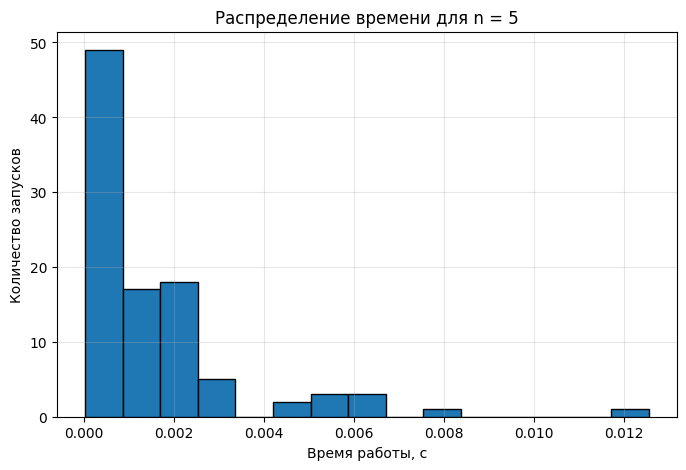

p_value: 0.000096
Гипотеза о нормальном распределении отвергается.
Время хорошее


In [13]:
import random
import time
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats


def time_one_run(edges):
    t1 = time.perf_counter()
    find_stable_matchings(edges)
    t2 = time.perf_counter()
    return t2 - t1


def make_edges(n, p=0.5):
    edges = []
    for i in range(n):
        for j in range(n):
            if random.random() < p:
                edges.append((f'x{i}', f'y{j}'))
    return edges


# Зависимость времени от n 

n_list = [2, 3, 4, 5, 6, 7]
means = []
stds = []

for n in n_list:
    times = []
    for i in range(10):
        g = make_edges(n)
        if len(g) >= n:
            times.append(time_one_run(g))

    means.append(np.mean(times))
    stds.append(np.std(times))

    print(f"n = {n}: среднее = {means[-1]:.6f}, СКО = {stds[-1]:.6f}")


plt.figure(figsize=(8, 5))
plt.plot(n_list, means, 'o-', label='Среднее время')
plt.fill_between(
    n_list,
    np.array(means) - 2 * np.array(stds),
    np.array(means) + 2 * np.array(stds),
    alpha=0.2,
    label='± 2 СКО'
)
plt.xlabel('Размер графа n')
plt.ylabel('Время работы, с')
plt.title('Зависимость времени работы от размера входа')
plt.grid(True)
plt.legend()
plt.show()


# Гистограмма для n 

n = 5
times = []

for i in range(100):
    g = make_edges(n)
    if len(g) >= n:
        times.append(time_one_run(g))

mean_t = np.mean(times)
std_t = np.std(times)

print(f"\nМат. ожидание: {mean_t:.6f}")
print(f"СКО: {std_t:.6f}")



plt.figure(figsize=(8, 5))
plt.hist(times, bins=15, edgecolor='black')
plt.xlabel('Время работы, с')
plt.ylabel('Количество запусков')
plt.title(f'Распределение времени для n = {n}')
plt.grid(True, alpha=0.3)
plt.show()


# Проверка гипотезы 

mu = np.mean(times)
sigma = np.std(times)

p = stats.kstest(times, 'norm', args=(mu, sigma)).pvalue
print(f'p_value: {p:.6f}')

if p > 0.05:
    print("Гипотеза о нормальном распределении не отвергается.")
else:
    print("Гипотеза о нормальном распределении отвергается.")


# Оценка времени 

if mean_t < 0.01:
    print("Время хорошее")
elif mean_t < 0.3:
    print("Время среднее")
else:
    print("Время плохое")